CELL 1 — Load saved models and data

In [4]:
import numpy as np
import pandas as pd
import joblib, json
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

# Load everything saved from 02b
xgb_model = joblib.load('../models/xgboost_model.pkl')
scaler     = joblib.load('../models/scaler.pkl')
features   = json.load(open('../models/feature_list.json'))
X_test     = np.load('../data/X_test.npy')
y_test     = np.load('../data/y_test.npy')

print(f"✅ Model loaded")
print(f"✅ Test set: {X_test.shape[0]:,} rows | Features: {len(features)}")
print(f"✅ Features: {features}")

✅ Model loaded
✅ Test set: 310,997 rows | Features: 17
✅ Features: ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'WBC', 'Creatinine', 'Bilirubin_total', 'Lactate', 'Glucose', 'Hgb', 'pH', 'Age', 'HospAdmTime', 'ICULOS']


CELL 2 — SHAP Summary Plot (shows which features matter most)

Computing SHAP values (2-3 mins for large dataset)...
✅ SHAP values computed


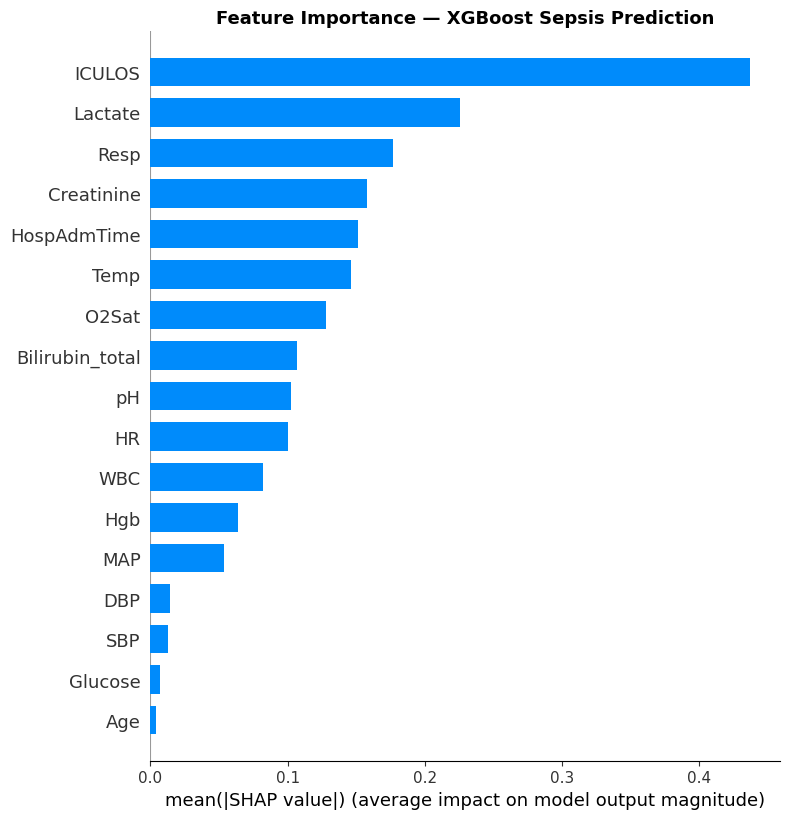

✅ Saved: outputs/03_shap_summary_bar.png


In [5]:
print("Computing SHAP values (2-3 mins for large dataset)...")

# Use a sample for speed — 5000 rows is enough for SHAP
sample_idx = np.random.choice(len(X_test), 5000, replace=False)
X_sample   = X_test[sample_idx]

# TreeExplainer is fast for XGBoost
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

print("✅ SHAP values computed")

# Summary plot — shows feature importance with direction
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_sample,
    feature_names=features,
    plot_type="bar",
    show=False
)
plt.title("Feature Importance — XGBoost Sepsis Prediction", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: outputs/03_shap_summary_bar.png")

CELL 3 — SHAP Beeswarm Plot (shows direction of impact)

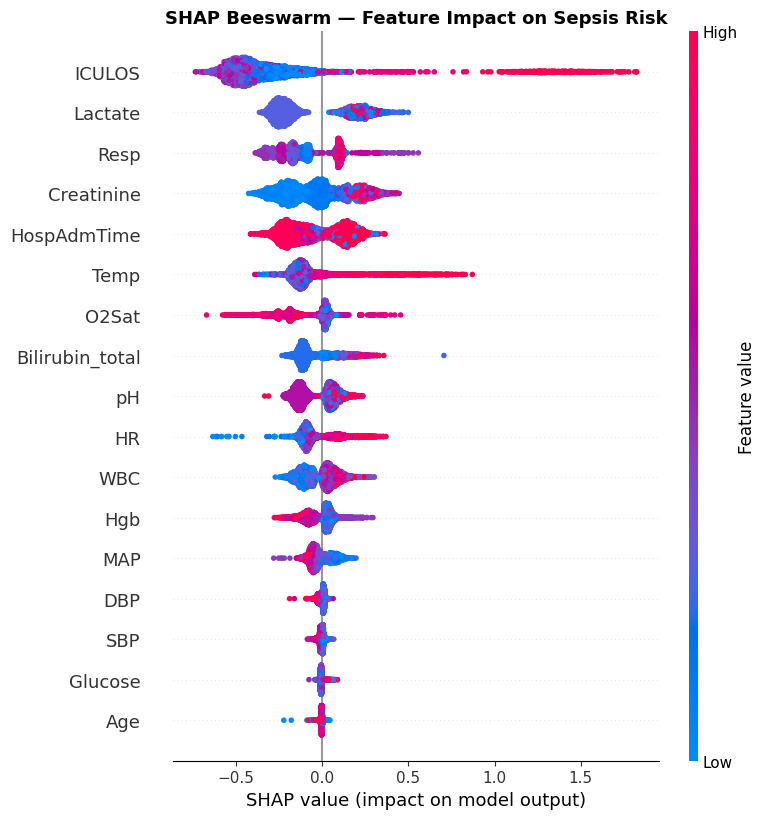

✅ Saved: outputs/03_shap_beeswarm.png


In [6]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_sample,
    feature_names=features,
    show=False
)
plt.title("SHAP Beeswarm — Feature Impact on Sepsis Risk", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: outputs/03_shap_beeswarm.png")

CELL 4 — SHAP Force Plots for 3 individual patients

Patient 1 — HIGH RISK | Predicted: 0.87 | Actual: 1


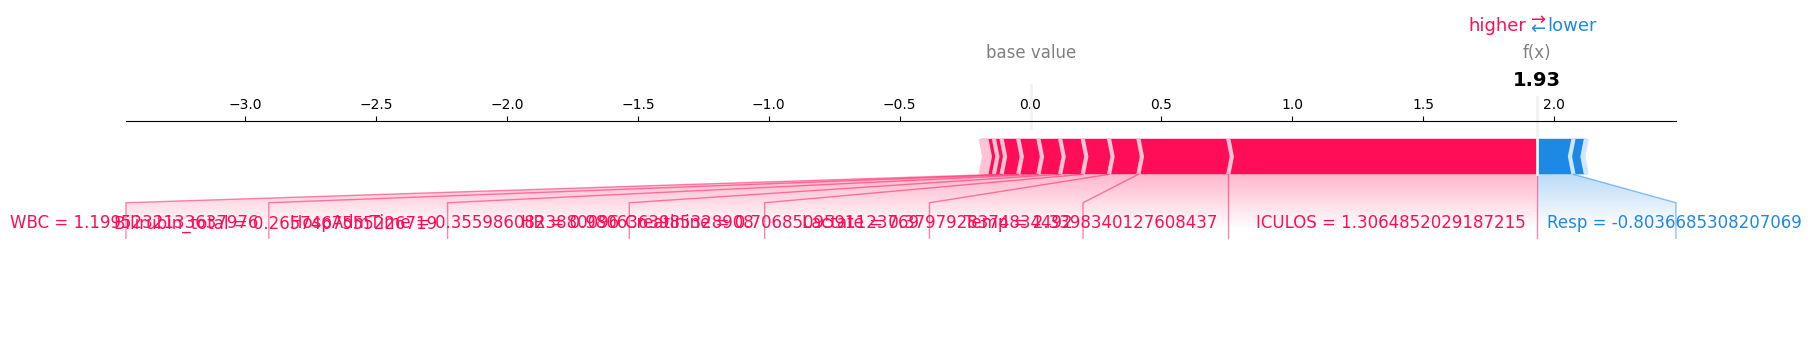


Patient 2 — LOW RISK | Predicted: 0.12 | Actual: 0


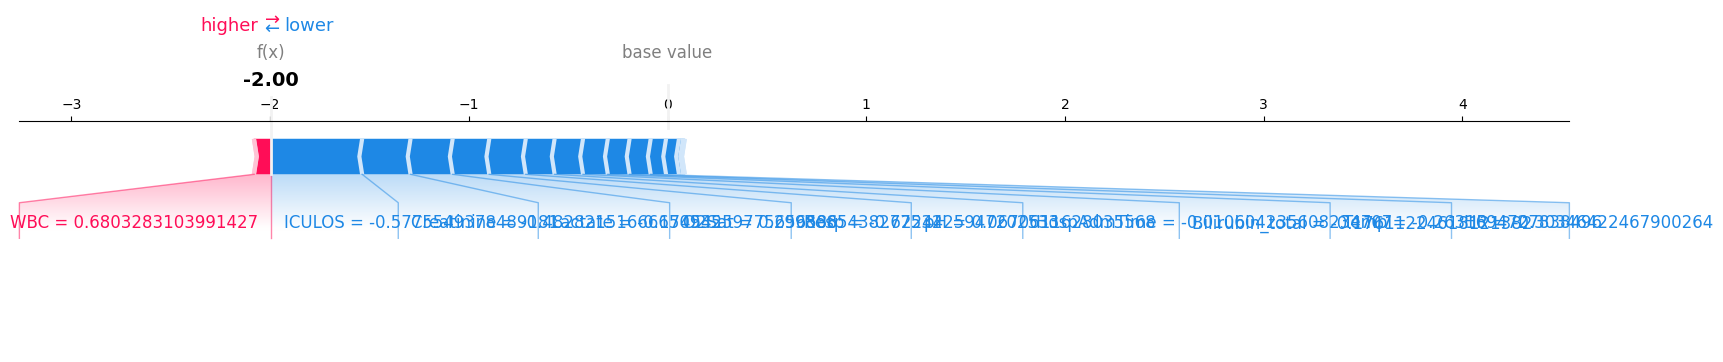

✅ Force plots saved to outputs/


In [7]:
# Find one high-risk and one low-risk patient for demo
xgb_proba = np.load('../data/xgb_proba_test.npy')
high_risk_idx = np.where((xgb_proba[sample_idx] > 0.7) & (y_test[sample_idx] == 1))[0]
low_risk_idx  = np.where((xgb_proba[sample_idx] < 0.2) & (y_test[sample_idx] == 0))[0]

shap.initjs()

# Patient 1 — High Risk
if len(high_risk_idx) > 0:
    i = high_risk_idx[0]
    print(f"Patient 1 — HIGH RISK | Predicted: {xgb_proba[sample_idx[i]]:.2f} | Actual: {y_test[sample_idx[i]]}")
    fp = shap.force_plot(
        explainer.expected_value,
        shap_values[i],
        X_sample[i],
        feature_names=features,
        matplotlib=True,
        show=False
    )
    plt.savefig('../outputs/03_force_plot_high_risk.png', dpi=150, bbox_inches='tight')
    plt.show()

# Patient 2 — Low Risk
if len(low_risk_idx) > 0:
    i = low_risk_idx[0]
    print(f"\nPatient 2 — LOW RISK | Predicted: {xgb_proba[sample_idx[i]]:.2f} | Actual: {y_test[sample_idx[i]]}")
    shap.force_plot(
        explainer.expected_value,
        shap_values[i],
        X_sample[i],
        feature_names=features,
        matplotlib=True,
        show=False
    )
    plt.savefig('../outputs/03_force_plot_low_risk.png', dpi=150, bbox_inches='tight')
    plt.show()

print("✅ Force plots saved to outputs/")

CELL 5 — Prepare LSTM sequences

In [ ]:
import pandas as pd

# Reload full data for sequence creation
df = pd.read_parquet('../data/combined_dataset.parquet')
features_list = json.load(open('../models/feature_list.json'))
available = [f for f in features_list if f in df.columns]

cols = ['PatientID', 'Hour', 'SepsisLabel'] + available
data = df[cols].copy()

# Impute
data[available] = data.groupby('PatientID')[available].transform(
    lambda x: x.ffill().bfill()
)
for col in available:
    data[col].fillna(data[col].median(), inplace=True)

WINDOW = 12  # 12 hours of history per prediction

def create_sequences(group, window=12):
    X_seq, y_seq = [], []
    vals  = group[available].values
    label = group['SepsisLabel'].values
    for i in range(window, len(vals)):
        X_seq.append(vals[i-window:i])
        y_seq.append(label[i])
    return X_seq, y_seq

print("Building sequences (5-8 mins)...")
all_X, all_y = [], []

for pid, group in data.groupby('PatientID'):
    if len(group) > WINDOW:
        Xs, ys = create_sequences(group.sort_values('Hour'))
        all_X.extend(Xs)
        all_y.extend(ys)

X_seq = np.array(all_X, dtype=np.float32)
y_seq = np.array(all_y, dtype=np.float32)

print(f"✅ Sequences: {X_seq.shape}  →  (samples, timesteps, features)")
print(f"   Positive rate: {y_seq.mean()*100:.1f}%")

np.save('../data/X_seq.npy', X_seq)
np.save('../data/y_seq.npy', y_seq)
print("✅ Sequences saved")

CELL 6 — Train LSTM

IMPORTANT: Upload X_seq.npy and y_seq.npy to Google Colab for free GPU
OR run locally if your PC can handle it

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

X_seq = np.load('../data/X_seq.npy')
y_seq = np.load('../data/y_seq.npy')

# Split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq
)

# Convert to tensors
X_tr_t = torch.tensor(X_tr)
y_tr_t = torch.tensor(y_tr).unsqueeze(1)
X_te_t = torch.tensor(X_te)
y_te_t = torch.tensor(y_te).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=512, shuffle=True)

# LSTM model
class SepsisLSTM(nn.Module):
    def __init__(self, input_size, hidden=64, layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, layers,
                            batch_first=True, dropout=dropout)
        self.fc   = nn.Linear(hidden, 1)
        self.sig  = nn.Sigmoid()
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.sig(self.fc(out[:, -1, :]))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

n_features = X_seq.shape[2]
model = SepsisLSTM(input_size=n_features).to(device)

pos_weight = torch.tensor([y_tr.mean()]).to(device)
criterion  = nn.BCELoss()
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training loop
best_loss = float('inf')
patience_count = 0
PATIENCE = 5

print("Training LSTM...")
for epoch in range(30):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # Validation
    model.eval()
    with torch.no_grad():
        val_pred = model(X_te_t.to(device)).cpu().numpy().flatten()
    from sklearn.metrics import roc_auc_score
    val_auroc = roc_auc_score(y_te, val_pred)

    print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | Val AUROC: {val_auroc:.4f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        patience_count = 0
        torch.save(model.state_dict(), '../models/lstm_best.pt')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"\n✅ LSTM training complete | Best model saved to models/lstm_best.pt")

CELL 7 — Final 3-Model Comparison Table

In [ ]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

# Load all results
xgb_model  = joblib.load('../models/xgboost_model.pkl')
lr_model   = joblib.load('../models/logistic_regression.pkl')
scaler     = joblib.load('../models/scaler.pkl')
X_test     = np.load('../data/X_test.npy')
y_test     = np.load('../data/y_test.npy')

X_test_sc  = scaler.transform(X_test)

# Get predictions
lr_proba  = lr_model.predict_proba(X_test_sc)[:, 1]
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

lr_pred   = (lr_proba  >= 0.3).astype(int)
xgb_pred  = (xgb_proba >= 0.3).astype(int)

# LSTM predictions
model.load_state_dict(torch.load('../models/lstm_best.pt'))
model.eval()
X_te_seq = np.load('../data/X_seq.npy')[-len(X_test):]
with torch.no_grad():
    lstm_proba = model(torch.tensor(X_te_seq[:len(y_test)]).to(device)).cpu().numpy().flatten()
lstm_pred = (lstm_proba >= 0.3).astype(int)

# Build table
results = pd.DataFrame({
    'Model':     ['Logistic Regression', 'XGBoost', 'LSTM (PyTorch)'],
    'AUROC':     [round(roc_auc_score(y_test, lr_proba), 4),
                  round(roc_auc_score(y_test, xgb_proba), 4),
                  round(roc_auc_score(y_test[:len(lstm_proba)], lstm_proba), 4)],
    'F1':        [round(f1_score(y_test, lr_pred), 4),
                  round(f1_score(y_test, xgb_pred), 4),
                  round(f1_score(y_test[:len(lstm_pred)], lstm_pred), 4)],
    'Precision': [round(precision_score(y_test, lr_pred), 4),
                  round(precision_score(y_test, xgb_pred), 4),
                  round(precision_score(y_test[:len(lstm_pred)], lstm_pred), 4)],
    'Recall':    [round(recall_score(y_test, lr_pred), 4),
                  round(recall_score(y_test, xgb_pred), 4),
                  round(recall_score(y_test[:len(lstm_pred)], lstm_pred), 4)],
})

print("="*60)
print("FINAL 3-MODEL COMPARISON")
print("="*60)
print(results.to_string(index=False))
results.to_csv('../outputs/03_model_comparison_final.csv', index=False)
print("\n✅ Comparison table saved to outputs/")